# ECG & Multi-Modal Data EDA

Exploratory data analysis for Subject 001 - visualizing ECG, CGM (glucose), and ABPM (blood pressure) data to check signal quality and temporal alignment.

In [1]:
import sys
from pathlib import Path
from datetime import datetime, timedelta

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Add src to path for imports
project_root = Path.cwd().parent
sys.path.insert(0, str(project_root / "src"))

from preprocessing.data_loader import DataLoader

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11

print("Setup complete!")

Setup complete!


In [ ]:
# Initialize DataLoader and load data for Subject 001
raw_data_path = project_root / "data" / "raw"
loader = DataLoader(str(raw_data_path))

subject_id = "001"

# Load ABPM data
abpm_df = loader.get_abpm(subject_id)
print(f"ABPM shape: {abpm_df.shape}")

# Load CGM data: CSV has a metadata row before the real headers
cgm_df = loader.get_cgm(subject_id)
cgm_df.columns = cgm_df.iloc[0]          # Real headers are in the first data row
cgm_df = cgm_df.iloc[1:].reset_index(drop=True)
cgm_df.columns = cgm_df.columns.str.strip()  # Remove accidental whitespace
print(f"CGM shape: {cgm_df.shape}")
print(f"CGM columns: {cgm_df.columns.tolist()}")

# Get ECG file paths
ecg_paths = loader.get_ecg_paths(subject_id)
print(f"ECG files found: {len(ecg_paths)}")
for p in ecg_paths:
    print(f"  - {p.name}")

ABPM shape: (49, 10)
CGM shape: (663, 19)
CGM columns: ['Device', 'Serial Number', 'Device Timestamp', 'Record Type', 'Historic Glucose mmol/L', 'Scan Glucose mmol/L', 'Non-numeric Rapid-Acting Insulin', 'Rapid-Acting Insulin (units)', 'Non-numeric Food', 'Carbohydrates (grams)', 'Carbohydrates (servings)', 'Non-numeric Long-Acting Insulin', 'Long-Acting Insulin Value (units)', 'Notes', 'Strip Glucose mmol/L', 'Ketone mmol/L', 'Meal Insulin (units)', 'Correction Insulin (units)', 'User Change Insulin (units)']
ECG files found: 3
  - 2022_06_06__10_28_26_ECG.csv
  - 2022_06_06__15_38_43_ECG.csv
  - 2022_06_07__10_42_46_ECG.csv


In [3]:
# Parse timestamps for all data sources

# ECG: Get start/end times from filenames and file contents
ecg_times = []
for path in ecg_paths:
    # Parse datetime from filename (e.g., 2022_06_06__10_28_26_ECG.csv)
    name_parts = path.stem.replace("_ECG", "").split("__")
    date_str = name_parts[0]  # 2022_06_06
    time_str = name_parts[1]  # 10_28_26
    dt = datetime.strptime(f"{date_str}_{time_str}", "%Y_%m_%d_%H_%M_%S")
    ecg_times.append(dt)

# Use first ECG file date as base date for ABPM
base_date = ecg_times[0].date()
print(f"Base date from ECG: {base_date}")

# CGM: Parse Device Timestamp column
cgm_df['timestamp'] = pd.to_datetime(cgm_df['Device Timestamp'], format='%d/%m/%Y %H:%M')
cgm_df['glucose'] = pd.to_numeric(cgm_df['Historic Glucose mmol/L'], errors='coerce')
print(f"CGM time range: {cgm_df['timestamp'].min()} to {cgm_df['timestamp'].max()}")

# ABPM: Parse Time column and infer date from base_date
def parse_abpm_time(time_str, base_date):
    """Parse ABPM time string and add date."""
    try:
        # Handle formats like "11:17 Mon", "11:17", "00:09 Tue"
        time_str = str(time_str).strip()
        time_part = time_str.split()[0]  # Get just the time
        hour, minute = map(int, time_part.split(':'))
        return datetime.combine(base_date, datetime.min.time().replace(hour=hour, minute=minute))
    except:
        return None

abpm_df['timestamp'] = abpm_df['Time'].apply(lambda x: parse_abpm_time(x, base_date))

# Adjust dates for times that wrap past midnight
prev_time = None
date_offset = timedelta(days=0)
timestamps = []
for idx, row in abpm_df.iterrows():
    ts = row['timestamp']
    if ts is not None:
        if prev_time is not None and ts.hour < prev_time.hour and prev_time.hour > 20:
            date_offset += timedelta(days=1)
        ts = ts + date_offset
        prev_time = row['timestamp']
    timestamps.append(ts)
abpm_df['timestamp'] = timestamps

# Filter valid BP readings (non-zero)
abpm_valid = abpm_df[(abpm_df['Systolic'].str.strip() != '0') & (abpm_df['timestamp'].notna())].copy()
abpm_valid['Systolic'] = pd.to_numeric(abpm_valid['Systolic'].str.strip(), errors='coerce')
abpm_valid['Diastolic'] = pd.to_numeric(abpm_valid['Diastolic'].str.strip(), errors='coerce')
abpm_valid = abpm_valid.dropna(subset=['Systolic', 'Diastolic'])

print(f"ABPM valid readings: {len(abpm_valid)} / {len(abpm_df)}")
print(f"ABPM time range: {abpm_valid['timestamp'].min()} to {abpm_valid['timestamp'].max()}")

Base date from ECG: 2022-06-06
CGM time range: 2022-06-06 09:32:00 to 2022-06-13 16:49:00
ABPM valid readings: 40 / 49
ABPM time range: 2022-06-06 11:17:00 to 2022-06-07 11:09:00


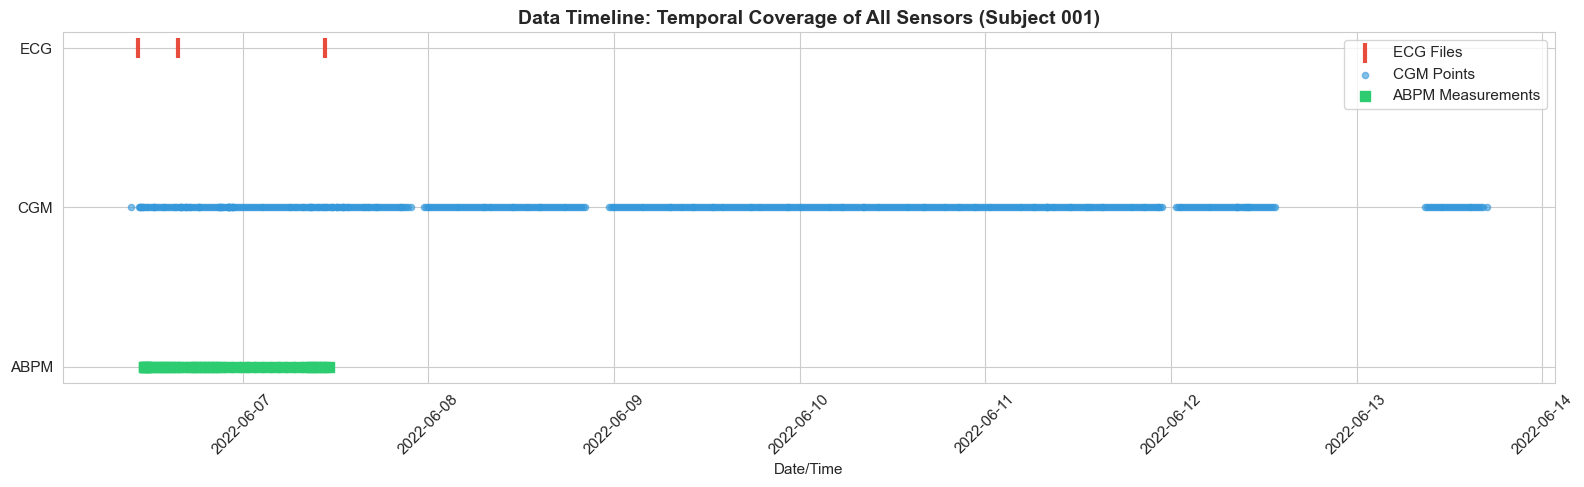


Timeline shows temporal overlap between sensors.


In [4]:
# PLOT 1: Data Timeline - When do we have data?
fig, ax = plt.subplots(figsize=(16, 5))

# ECG file time ranges (scatter at y=3)
for i, dt in enumerate(ecg_times):
    ax.scatter(dt, 3, s=200, c='#e74c3c', marker='|', linewidths=3, 
               label='ECG Files' if i == 0 else '')
    ax.annotate(ecg_paths[i].name[:16], (dt, 3.15), fontsize=8, rotation=45, ha='left')

# CGM data points (scatter at y=2)
ax.scatter(cgm_df['timestamp'], [2]*len(cgm_df), s=20, c='#3498db', alpha=0.6, label='CGM Points')

# ABPM measurements (scatter at y=1)
ax.scatter(abpm_valid['timestamp'], [1]*len(abpm_valid), s=50, c='#2ecc71', marker='s', label='ABPM Measurements')

# Formatting
ax.set_yticks([1, 2, 3])
ax.set_yticklabels(['ABPM', 'CGM', 'ECG'])
ax.set_xlabel('Date/Time')
ax.set_title('Data Timeline: Temporal Coverage of All Sensors (Subject 001)', fontsize=14, fontweight='bold')
ax.legend(loc='upper right')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("\nTimeline shows temporal overlap between sensors.")

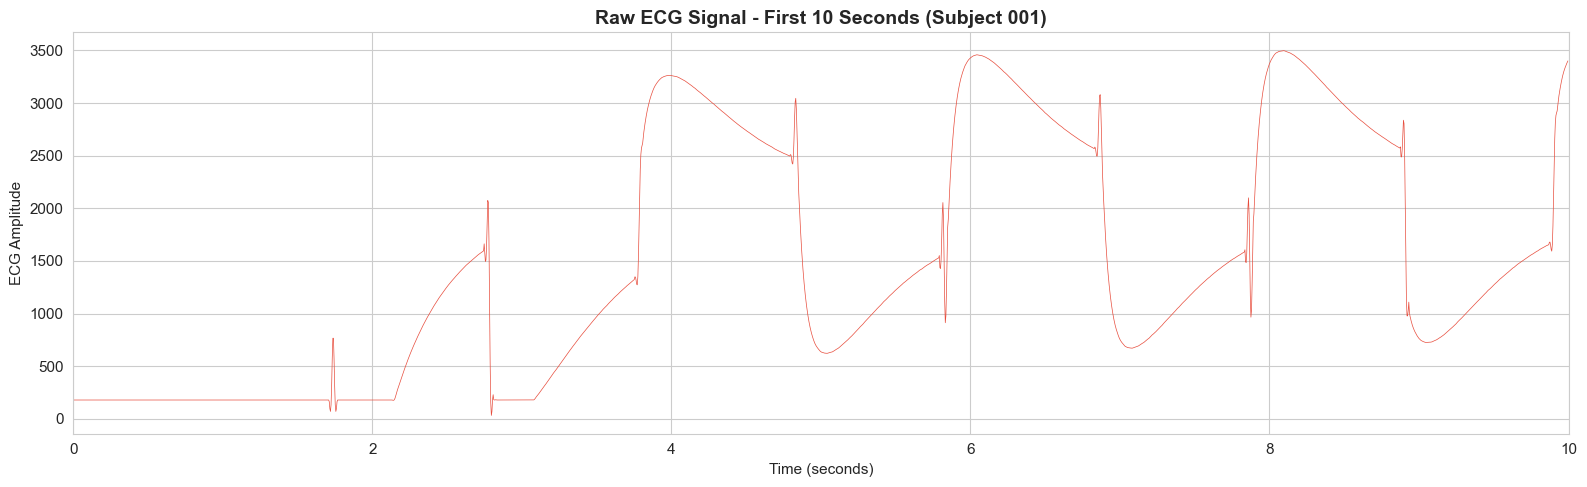

ECG file: 2022_06_06__10_28_26_ECG.csv
Total samples in file: 4,647,250
Sampling rate: ~250 Hz (4ms intervals)


In [5]:
# PLOT 2a: Raw ECG Signal (First 10 seconds)

# Load first ECG file
ecg_df = pd.read_csv(ecg_paths[0])
ecg_df['Time'] = pd.to_datetime(ecg_df['Time'])

# ECG sampling rate is ~250 Hz (4ms intervals)
# 10 seconds = 2500 samples
samples_10s = 2500
ecg_10s = ecg_df.head(samples_10s).copy()

# Create time axis in seconds
ecg_10s['seconds'] = (ecg_10s['Time'] - ecg_10s['Time'].iloc[0]).dt.total_seconds()

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(ecg_10s['seconds'], ecg_10s['EcgWaveform'], color='#e74c3c', linewidth=0.5)
ax.set_xlabel('Time (seconds)')
ax.set_ylabel('ECG Amplitude')
ax.set_title('Raw ECG Signal - First 10 Seconds (Subject 001)', fontsize=14, fontweight='bold')
ax.set_xlim(0, 10)
plt.tight_layout()
plt.show()

print(f"ECG file: {ecg_paths[0].name}")
print(f"Total samples in file: {len(ecg_df):,}")
print(f"Sampling rate: ~{1000 / 4:.0f} Hz (4ms intervals)")

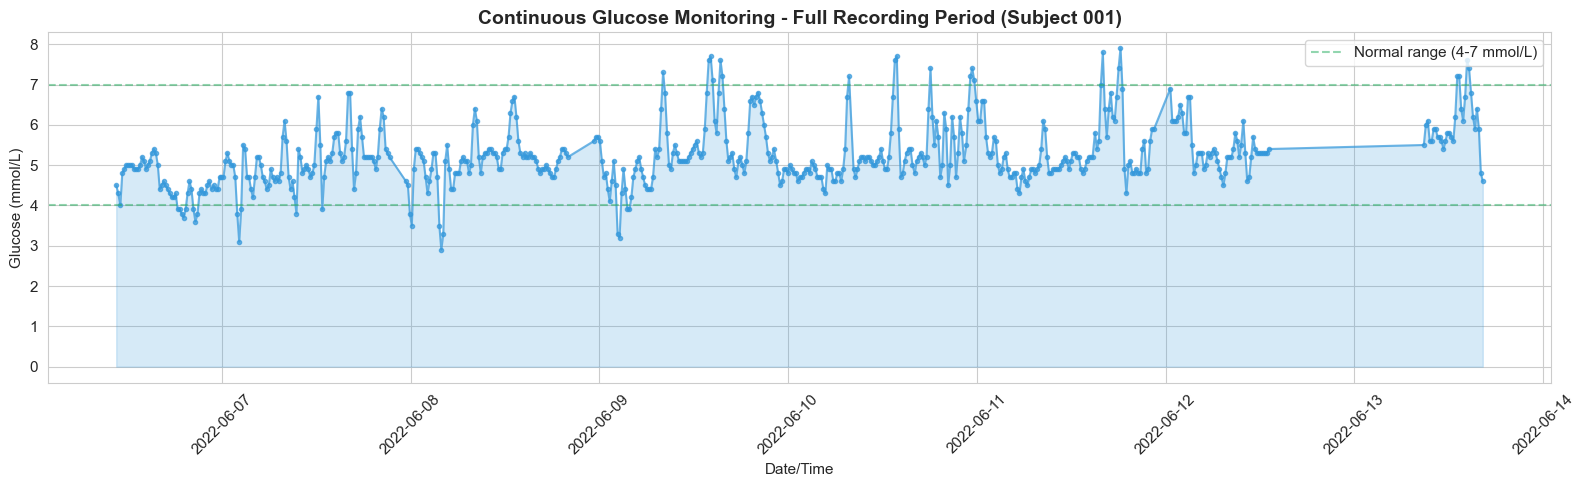

CGM readings: 663
Glucose range: 2.9 - 7.9 mmol/L
Mean glucose: 5.24 mmol/L


In [6]:
# PLOT 2b: 24-hour CGM (Glucose) Trend

fig, ax = plt.subplots(figsize=(16, 5))

# Plot glucose values
ax.plot(cgm_df['timestamp'], cgm_df['glucose'], color='#3498db', linewidth=1.5, marker='o', markersize=3, alpha=0.7)
ax.fill_between(cgm_df['timestamp'], cgm_df['glucose'], alpha=0.2, color='#3498db')

# Add reference lines for normal glucose range (4-7 mmol/L fasting)
ax.axhline(y=4, color='#27ae60', linestyle='--', alpha=0.5, label='Normal range (4-7 mmol/L)')
ax.axhline(y=7, color='#27ae60', linestyle='--', alpha=0.5)

ax.set_xlabel('Date/Time')
ax.set_ylabel('Glucose (mmol/L)')
ax.set_title('Continuous Glucose Monitoring - Full Recording Period (Subject 001)', fontsize=14, fontweight='bold')
ax.legend(loc='upper right')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(f"CGM readings: {len(cgm_df)}")
print(f"Glucose range: {cgm_df['glucose'].min():.1f} - {cgm_df['glucose'].max():.1f} mmol/L")
print(f"Mean glucose: {cgm_df['glucose'].mean():.2f} mmol/L")

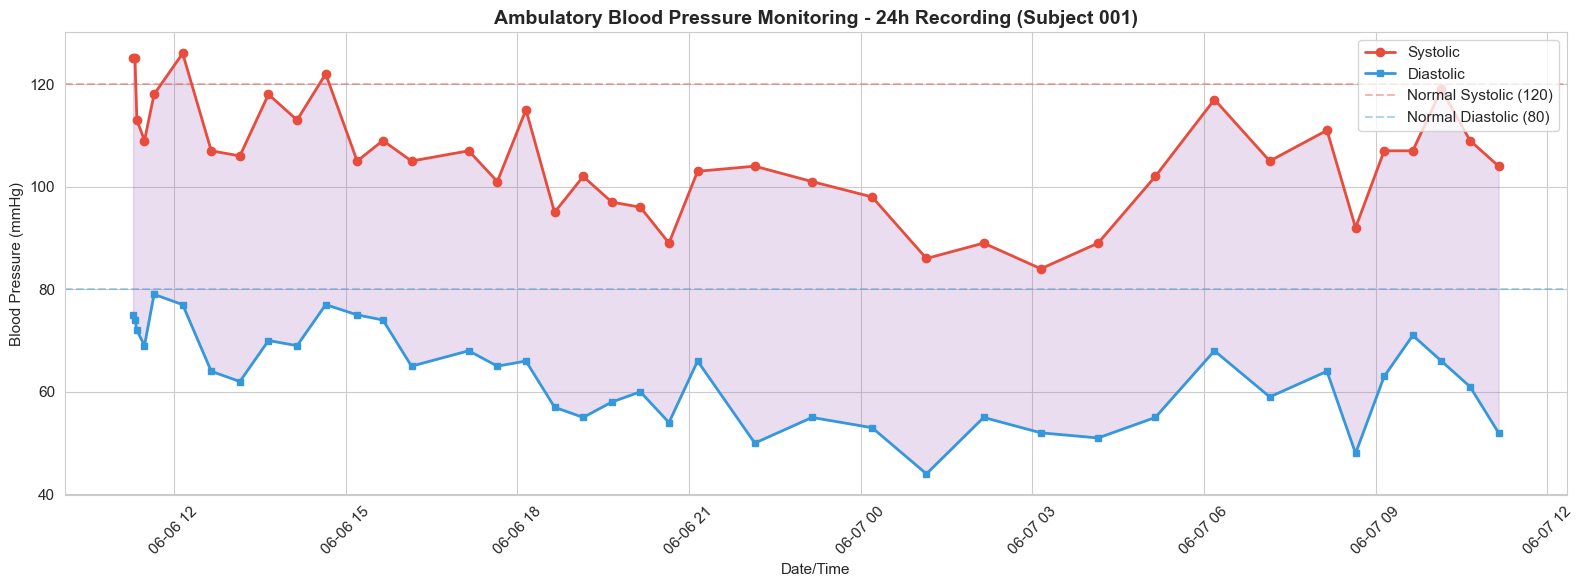

Valid BP readings: 40
Systolic range: 84 - 126 mmHg
Diastolic range: 44 - 79 mmHg
Mean BP: 106/63 mmHg


In [7]:
# PLOT 2c: Blood Pressure Over Time (Systolic & Diastolic)

fig, ax = plt.subplots(figsize=(16, 6))

# Plot Systolic and Diastolic
ax.plot(abpm_valid['timestamp'], abpm_valid['Systolic'], 
        color='#e74c3c', linewidth=2, marker='o', markersize=6, label='Systolic')
ax.plot(abpm_valid['timestamp'], abpm_valid['Diastolic'], 
        color='#3498db', linewidth=2, marker='s', markersize=5, label='Diastolic')

# Fill between for visual effect
ax.fill_between(abpm_valid['timestamp'], abpm_valid['Systolic'], abpm_valid['Diastolic'], 
                alpha=0.2, color='#9b59b6')

# Reference lines for normal BP (120/80)
ax.axhline(y=120, color='#e74c3c', linestyle='--', alpha=0.4, label='Normal Systolic (120)')
ax.axhline(y=80, color='#3498db', linestyle='--', alpha=0.4, label='Normal Diastolic (80)')

ax.set_xlabel('Date/Time')
ax.set_ylabel('Blood Pressure (mmHg)')
ax.set_title('Ambulatory Blood Pressure Monitoring - 24h Recording (Subject 001)', fontsize=14, fontweight='bold')
ax.legend(loc='upper right')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(f"Valid BP readings: {len(abpm_valid)}")
print(f"Systolic range: {abpm_valid['Systolic'].min():.0f} - {abpm_valid['Systolic'].max():.0f} mmHg")
print(f"Diastolic range: {abpm_valid['Diastolic'].min():.0f} - {abpm_valid['Diastolic'].max():.0f} mmHg")
print(f"Mean BP: {abpm_valid['Systolic'].mean():.0f}/{abpm_valid['Diastolic'].mean():.0f} mmHg")